# TTFT breakdown & CDF — 検証2-1-1(N=50, 2:1トラフィック, RTX4090)

`Diary/output/2026-07-05-exp211-nokv-n50-2to1-rtx4090-report.md` の結果を再現するノートブックです。

- 方法A: `NEAREST`(キューで待つ)
- 方法B: `NEAREST_MIGRATE`(キャパ超過時にGPU間バックボーンでリダイレクト、KVキャッシュは考慮しない)

読み込むCSV(`python -m serving`の出力):
- `kondoFolder/experiment_1/run_n50_nearest.csv`
- `kondoFolder/experiment_1/run_n50_migrate.csv`

このノートブックは**リポジトリのルートディレクトリから見た相対パス**でCSVを読みます。
`REPO_ROOT`を書き換えれば別のマシン/別の実行結果にもそのまま使えます。


In [1]:
import csv
import statistics as st
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------------------------------------------------------------------------
# Config — edit these to point at a different run
# ---------------------------------------------------------------------------

def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing both
    `kondoFolder/` and `serving/` is found (works whether this notebook is
    run from the repo root or from its own outputs/image/ location)."""
    cur = start.resolve()
    for _ in range(6):
        if (cur / "kondoFolder").exists() and (cur / "serving").exists():
            return cur
        cur = cur.parent
    raise RuntimeError(
        "Could not locate repo root (looked for kondoFolder/ and serving/ "
        "within 6 parent levels of " + str(start))


REPO_ROOT = find_repo_root(Path.cwd())
NEAREST_CSV = REPO_ROOT / "kondoFolder/experiment_1/run_n50_nearest.csv"
MIGRATE_CSV = REPO_ROOT / "kondoFolder/experiment_1/run_n50_migrate.csv"
OUT_DIR = REPO_ROOT / "outputs/image"
PREFIX = "2026-07-05_exp211_n50_2to1_rtx4090"

LABEL_A = "Method A (NEAREST)"
LABEL_B = "Method B (NEAREST_MIGRATE)"

# Reference palette (dataviz skill, light-mode categorical slots)
COLOR_QUEUE = "#2a78d6"    # blue
COLOR_COMPUTE = "#1baf7a"  # aqua
COLOR_RTT = "#eda100"      # yellow
COLOR_A = "#2a78d6"        # blue
COLOR_B = "#e34948"        # red
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

print("REPO_ROOT =", REPO_ROOT)


REPO_ROOT = /Users/taichikondo/LLMServingSim


In [2]:
def load_rows(path):
    with open(path, newline="") as f:
        return list(csv.DictReader(f))


def ttft_list(rows):
    return sorted(float(r["e2e_ttft_ns"]) / 1e6 for r in rows if float(r["e2e_ttft_ns"]) >= 0)


def breakdown(rows):
    """Mean (queue, compute/prefill, RTT/communication) in ms."""
    q = [float(r["queueing_before_ttft_ns"]) / 1e6 for r in rows]
    pf = [float(r["prefill_service_ns"]) / 1e6 for r in rows]
    rtt = [float(r["communication_latency_ns"]) / 1e6 for r in rows]
    return st.mean(q), st.mean(pf), st.mean(rtt)


def pct(sorted_vals, q):
    pos = (len(sorted_vals) - 1) * q
    lo = int(pos)
    hi = min(lo + 1, len(sorted_vals) - 1)
    frac = pos - lo
    return sorted_vals[lo] * (1 - frac) + sorted_vals[hi] * frac


rows_a = load_rows(NEAREST_CSV)
rows_b = load_rows(MIGRATE_CSV)

break_a = breakdown(rows_a)
break_b = breakdown(rows_b)
a_ttft = ttft_list(rows_a)
b_ttft = ttft_list(rows_b)

print("Method A breakdown (queue, compute, rtt):", break_a)
print("Method B breakdown (queue, compute, rtt):", break_b)
print(f"Method A p50/p99 TTFT: {pct(a_ttft,0.5):.1f}ms / {pct(a_ttft,0.99):.1f}ms")
print(f"Method B p50/p99 TTFT: {pct(b_ttft,0.5):.1f}ms / {pct(b_ttft,0.99):.1f}ms")


Method A breakdown (queue, compute, rtt): (238.19102524, 105.33836808, 3.3931142)
Method B breakdown (queue, compute, rtt): (215.64168145999997, 105.3897339, 3.400502)
Method A p50/p99 TTFT: 108.3ms / 5640.9ms
Method B p50/p99 TTFT: 112.6ms / 5116.3ms


## 1. 平均TTFTの内訳(Queue + Compute + RTT)


wrote /Users/taichikondo/LLMServingSim/outputs/image/2026-07-05_exp211_n50_2to1_rtx4090_ttft_breakdown.png


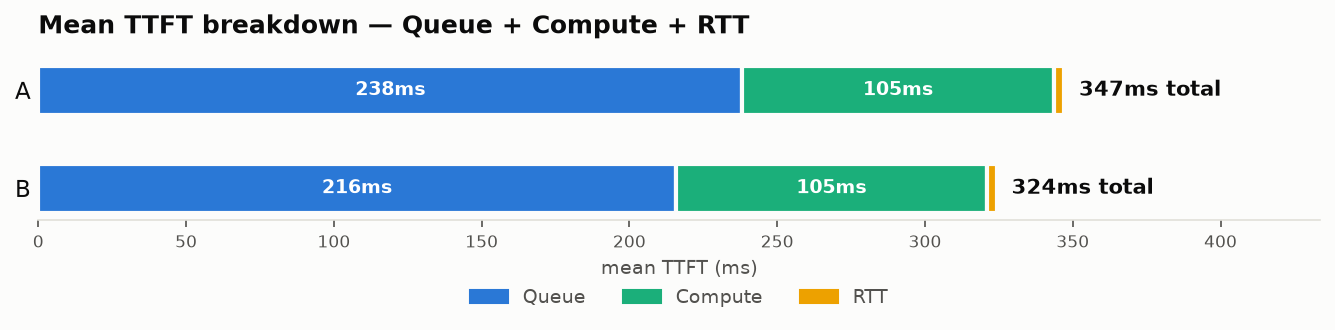

In [3]:
def plot_breakdown(break_a, break_b, out_path=None):
    fig, ax = plt.subplots(figsize=(9, 2.6), dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    names = ["Queue", "Compute", "RTT"]
    colors = [COLOR_QUEUE, COLOR_COMPUTE, COLOR_RTT]
    rows = [("A", break_a), ("B", break_b)]

    bar_h = 0.5
    y_positions = [1, 0]
    for (label, vals), y in zip(rows, y_positions):
        left = 0
        total = sum(vals)
        for v, c, name in zip(vals, colors, names):
            ax.barh(y, v, left=left, height=bar_h, color=c, edgecolor=SURFACE, linewidth=2)
            if v / total > 0.06:  # only label segments wide enough to read
                ax.text(left + v / 2, y, f"{v:.0f}ms", ha="center", va="center",
                        color="white", fontsize=9, fontweight="bold")
            left += v
        ax.text(left + total * 0.015, y, f"{total:.0f}ms total", ha="left", va="center",
                 color=TEXT_PRIMARY, fontsize=10, fontweight="bold")

    ax.set_yticks(y_positions)
    ax.set_yticklabels(["A", "B"], fontsize=11, color=TEXT_PRIMARY)
    ax.set_xlabel("mean TTFT (ms)", fontsize=9, color=TEXT_SECONDARY)
    ax.set_xlim(0, max(sum(break_a), sum(break_b)) * 1.25)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(axis="x", colors=TEXT_SECONDARY, labelsize=8)
    ax.tick_params(axis="y", length=0)
    ax.set_title("Mean TTFT breakdown — Queue + Compute + RTT", fontsize=12,
                  color=TEXT_PRIMARY, loc="left", fontweight="bold", pad=12)

    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
    ax.legend(handles, names, loc="upper center", bbox_to_anchor=(0.5, -0.32),
              ncol=3, frameon=False, fontsize=9, labelcolor=TEXT_SECONDARY)

    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, facecolor=SURFACE)
        print(f"wrote {out_path}")
    return fig


OUT_DIR.mkdir(parents=True, exist_ok=True)
fig1 = plot_breakdown(break_a, break_b, OUT_DIR / f"{PREFIX}_ttft_breakdown.png")
plt.show()


## 2. TTFTの経験累積分布関数(CDF)

横軸は対数スケール(TTFTが90ms付近から5秒台まで裾を引くため)。p50/p99にマーカー。


wrote /Users/taichikondo/LLMServingSim/outputs/image/2026-07-05_exp211_n50_2to1_rtx4090_ttft_cdf.png


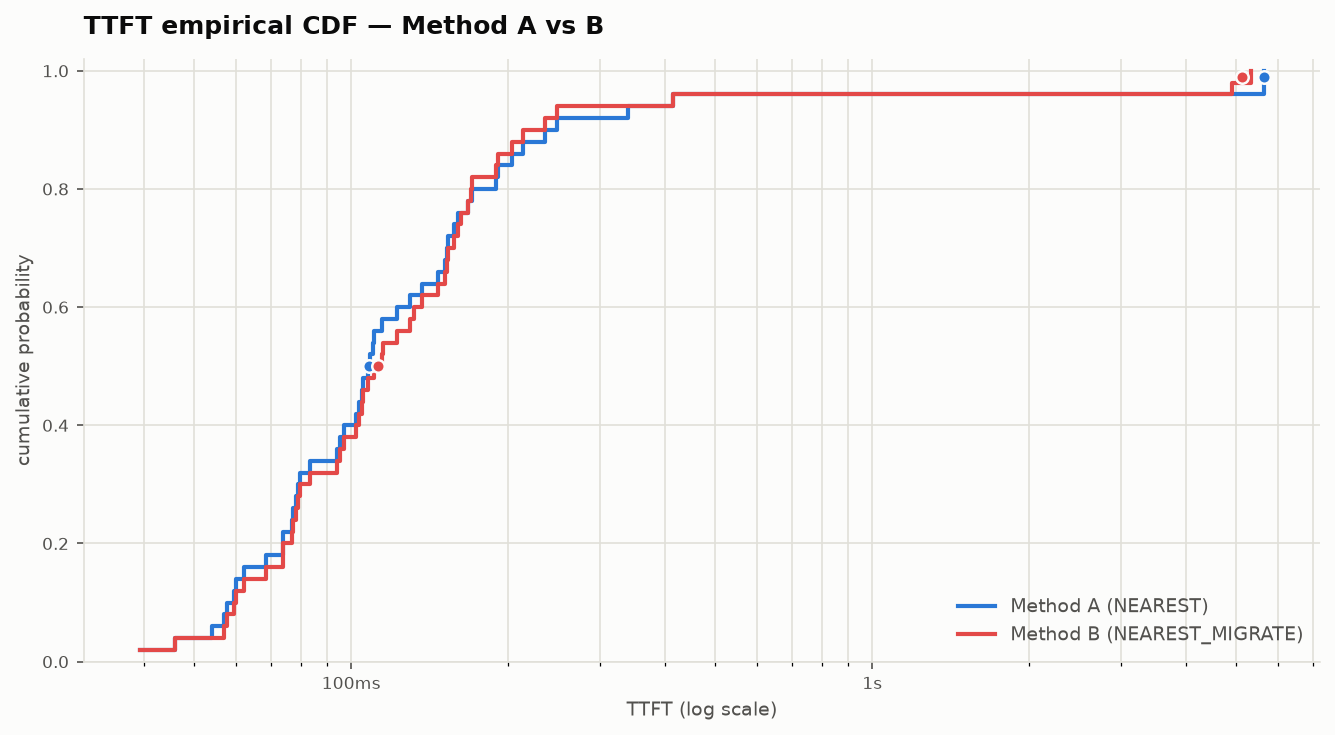

In [4]:
def plot_cdf(a_ttft, b_ttft, out_path=None):
    fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    for vals, color, label in [(a_ttft, COLOR_A, LABEL_A), (b_ttft, COLOR_B, LABEL_B)]:
        n = len(vals)
        ax.step(vals, [(i + 1) / n for i in range(n)], where="post", color=color,
                linewidth=2, label=label)

        p50 = pct(vals, 0.5)
        p99 = pct(vals, 0.99)
        ax.scatter([p50, p99], [0.5, 0.99], color=color, s=36, zorder=5,
                   edgecolor=SURFACE, linewidth=1.2)

    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1000:.0f}s" if x >= 1000 else f"{x:.0f}ms"))
    ax.set_xlabel("TTFT (log scale)", fontsize=9, color=TEXT_SECONDARY)
    ax.set_ylabel("cumulative probability", fontsize=9, color=TEXT_SECONDARY)
    ax.set_ylim(0, 1.02)
    ax.grid(True, which="both", color=GRID, linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)
    ax.set_title("TTFT empirical CDF — Method A vs B", fontsize=12, color=TEXT_PRIMARY,
                 loc="left", fontweight="bold", pad=12)
    ax.legend(loc="lower right", frameon=False, fontsize=9, labelcolor=TEXT_SECONDARY)

    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, facecolor=SURFACE)
        print(f"wrote {out_path}")
    return fig


fig2 = plot_cdf(a_ttft, b_ttft, OUT_DIR / f"{PREFIX}_ttft_cdf.png")
plt.show()


## 3. パーセンタイル表


In [5]:
import pandas as pd

pcts = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
table = pd.DataFrame({
    "percentile": [("min" if p == 0 else "max" if p == 1 else f"p{int(p*100)}") for p in pcts],
    "Method A (ms)": [round(pct(a_ttft, p), 1) for p in pcts],
    "Method B (ms)": [round(pct(b_ttft, p), 1) for p in pcts],
})
table


,percentile,Method A (ms),Method B (ms)
0,min,39.3,39.3
1,p10,59.4,60.0
2,p25,77.6,78.6
3,p50,108.3,112.6
4,p75,159.5,162.0
5,p90,236.7,216.2
6,p95,380.4,339.3
7,p99,5640.9,5116.3
8,max,5642.5,5328.6
